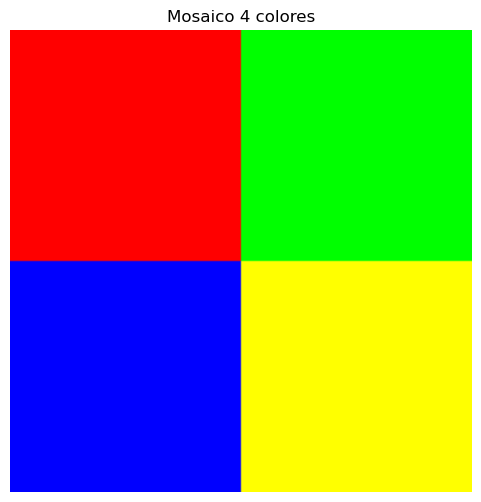

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = [6,6]

size_imagen = 100


R1 = np.ones((size_imagen, size_imagen)) * 255
G1 = np.zeros((size_imagen, size_imagen))
B1 = np.zeros((size_imagen, size_imagen))
img_rojo = np.dstack((R1, G1, B1))


R2 = np.zeros((size_imagen, size_imagen))
G2 = np.ones((size_imagen, size_imagen)) * 255
B2 = np.zeros((size_imagen, size_imagen))
img_verde = np.dstack((R2, G2, B2))


R3 = np.zeros((size_imagen, size_imagen))
G3 = np.zeros((size_imagen, size_imagen))
B3 = np.ones((size_imagen, size_imagen)) * 255
img_azul = np.dstack((R3, G3, B3))


R4 = np.ones((size_imagen, size_imagen)) * 255
G4 = np.ones((size_imagen, size_imagen)) * 255
B4 = np.zeros((size_imagen, size_imagen))
img_amarillo = np.dstack((R4, G4, B4))


img_rojo = img_rojo.astype(np.uint8)
img_verde = img_verde.astype(np.uint8)
img_azul = img_azul.astype(np.uint8)
img_amarillo = img_amarillo.astype(np.uint8)


fila_superior = np.hstack((img_rojo, img_verde))
fila_inferior = np.hstack((img_azul, img_amarillo))
mosaico = np.vstack((fila_superior, fila_inferior))


plt.imshow(mosaico)
plt.title('Mosaico 4 colores')
plt.axis('off')
plt.show()

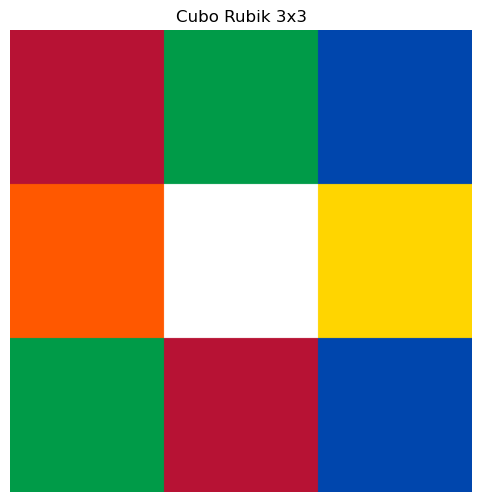

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = [6,6]

size_imagen = 100

def crear_color(r, g, b):
    R = np.ones((size_imagen, size_imagen)) * r
    G = np.ones((size_imagen, size_imagen)) * g
    B = np.ones((size_imagen, size_imagen)) * b
    img = np.dstack((R, G, B))
    return img.astype(np.uint8)

img_rojo     = crear_color(183, 18, 52)
img_verde    = crear_color(0, 155, 72)
img_azul     = crear_color(0, 70, 173)
img_amarillo = crear_color(255, 213, 0)
img_blanco   = crear_color(255, 255, 255)
img_naranja  = crear_color(255, 88, 0)

fila1 = np.hstack((img_rojo, img_verde, img_azul))
fila2 = np.hstack((img_naranja, img_blanco, img_amarillo))
fila3 = np.hstack((img_verde, img_rojo, img_azul))

mosaico = np.vstack((fila1, fila2, fila3))

plt.imshow(mosaico)
plt.title('Cubo Rubik 3x3')
plt.axis('off')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

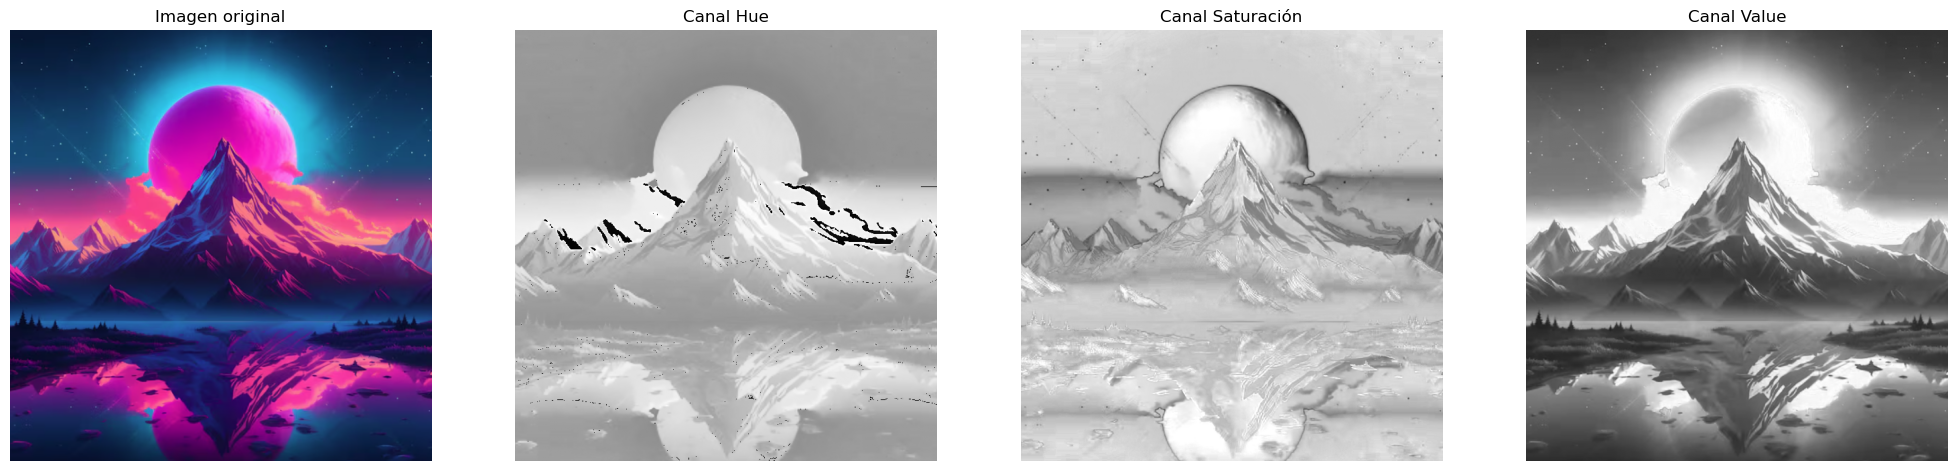

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen1 = cv2.imread('A.png')
img = cv2.cvtColor(imagen1, cv2.COLOR_BGR2RGB)

def RGB2HSV(img):
    img = img.astype(np.float32)
    img = img/255.
    new_img = np.zeros_like(img)

    maxChannel = np.argmax(img,axis=2)
    maxValue = np.amax(img,axis=2)
    minChannel = np.argmin(img,axis=2)
    minValue = np.amin(img,axis=2)
    #value 
    new_img[...,2] = maxValue

    #saturation
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j]==0:
                new_img[i,j,1] = 0
            elif maxValue[i,j] != 0:
                new_img[i,j,1] = (new_img[i,j,2]-minValue[i,j])/new_img[i,j,2]

    #hue 
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if sum(img[i,j,...])/3 == img[i,j,0]:
                new_img[i,j,0] = 0
            elif maxChannel[i,j] == 0: #R 
                new_img[i,j,0] = 60 * ((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))
            elif maxChannel[i,j] == 1: #G
                new_img[i,j,0] = 120 + 60 * (img[i,j,2]-img[i,j,0])/(new_img[i,j,2]-minValue[i,j])
            elif maxChannel[i,j] == 2: #B
                new_img[i,j,0] = 240 + 60 * (img[i,j,0]-img[i,j,1])/(new_img[i,j,2]-minValue[i,j])

        img2= new_img[...,0] < 0
        new_img[img2,0]   =  new_img[img2,0] + 360
    return new_img
hsv_img = RGB2HSV(img)

fig, axs = plt.subplots(1, 4, figsize=(25, 10))

axs[0].imshow(img)
axs[0].set_title('Imagen original')

axs[1].imshow(hsv_img[..., 0], cmap='gray', vmin=0, vmax=360)
axs[1].set_title('Canal Hue')

axs[2].imshow(hsv_img[..., 1], cmap='gray', vmin=0, vmax=1)
axs[2].set_title('Canal Saturación')

axs[3].imshow(hsv_img[..., 2], cmap='gray', vmin=0, vmax=1)
axs[3].set_title('Canal Value')

for ax in axs:
    ax.axis('off')
plt.show


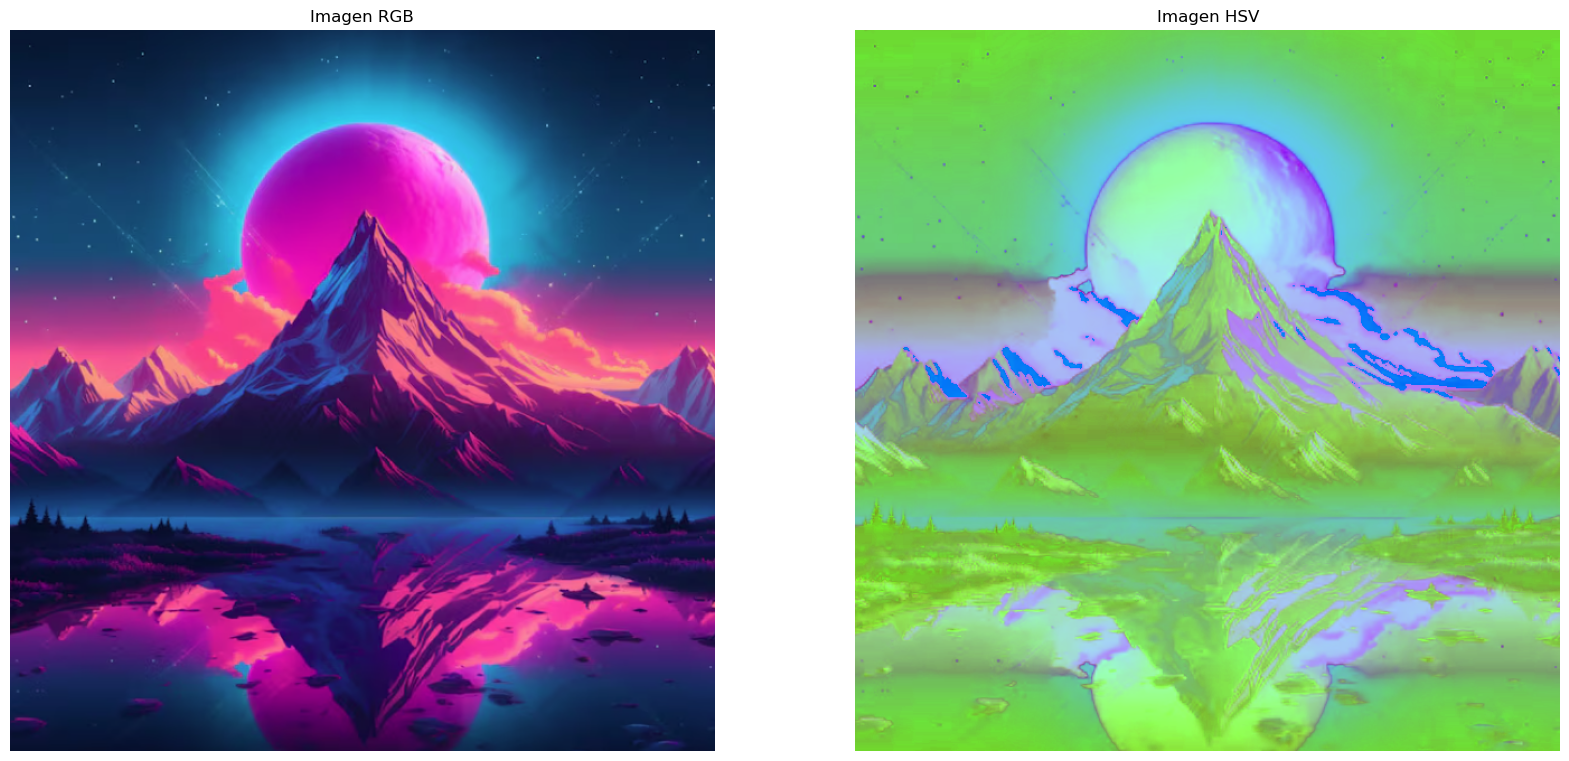

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv2.imread('A.png', cv2.IMREAD_COLOR)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

fig, axs = plt.subplots(1, 2, figsize=(20, 10))

axs[0].imshow(img_rgb)
axs[0].set_title("Imagen RGB")
axs[0].axis("off")

axs[1].imshow(img_hsv)
axs[1].set_title("Imagen HSV")
axs[1].axis("off")

plt.show()

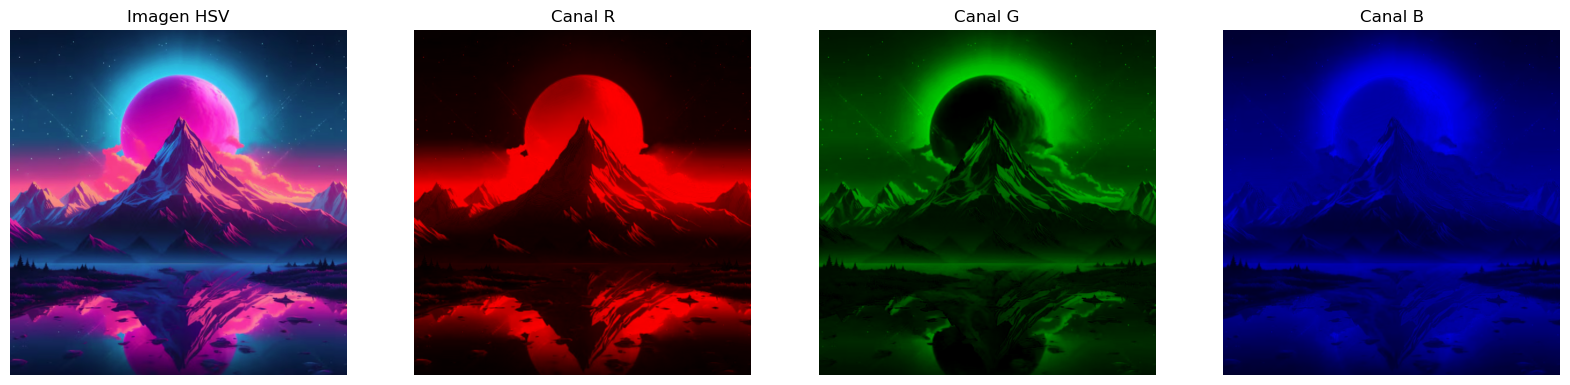

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def hcv_to_rgb_manual(H, S, V):

    C = V * S
    X = C * (1 - np.abs(((H / 60) % 2) - 1))
    m = V - C

    R_p = np.zeros_like(H)
    G_p = np.zeros_like(H)
    B_p = np.zeros_like(H)

    cond1 = (0 <= H) & (H < 60)
    cond2 = (60 <= H) & (H < 120)
    cond3 = (120 <= H) & (H < 180)
    cond4 = (180 <= H) & (H < 240)
    cond5 = (240 <= H) & (H < 300)
    cond6 = (300 <= H) & (H < 360)

    R_p[cond1], G_p[cond1], B_p[cond1] = C[cond1], X[cond1], 0
    R_p[cond2], G_p[cond2], B_p[cond2] = X[cond2], C[cond2], 0
    R_p[cond3], G_p[cond3], B_p[cond3] = 0, C[cond3], X[cond3]
    R_p[cond4], G_p[cond4], B_p[cond4] = 0, X[cond4], C[cond4]
    R_p[cond5], G_p[cond5], B_p[cond5] = X[cond5], 0, C[cond5]
    R_p[cond6], G_p[cond6], B_p[cond6] = C[cond6], 0, X[cond6]

    R = ((R_p + m) * 255).astype(np.uint8)
    G = ((G_p + m) * 255).astype(np.uint8)
    B = ((B_p + m) * 255).astype(np.uint8)

    return R, G, B
def mostrar_hcv_rgb(img_path):

    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)

    H = img_hsv[:, :, 0] * 2
    S = img_hsv[:, :, 1] / 255.0
    V = img_hsv[:, :, 2] / 255.0

    R, G, B = hcv_to_rgb_manual(H, S, V)


    img_rgb_manual = np.dstack((R, G, B))

    R_img = np.zeros_like(img_rgb_manual)
    G_img = np.zeros_like(img_rgb_manual)
    B_img = np.zeros_like(img_rgb_manual)

    R_img[:, :, 0] = R
    G_img[:, :, 1] = G
    B_img[:, :, 2] = B

    H_vis = (H / 2).astype(np.uint8)
    S_vis = (S * 255).astype(np.uint8)
    V_vis = (V * 255).astype(np.uint8)

    img_hsv_visible = cv2.merge([H_vis, S_vis, V_vis])
    img_hcv_visible = cv2.cvtColor(img_hsv_visible, cv2.COLOR_HSV2RGB)

    fig, axs = plt.subplots(1, 4, figsize=(20, 5))

    axs[0].imshow(img_hcv_visible)
    axs[0].set_title("Imagen HSV")
    axs[0].axis("off")

    axs[1].imshow(R_img)
    axs[1].set_title("Canal R")
    axs[1].axis("off")

    axs[2].imshow(G_img)
    axs[2].set_title("Canal G")
    axs[2].axis("off")

    axs[3].imshow(B_img)
    axs[3].set_title("Canal B")
    axs[3].axis("off")
  

    plt.show()


mostrar_hcv_rgb("A.png")